In [1]:
import numpy as np
from matplotlib import pyplot as plt

$y''=2y+xe^{-x}$

$y'=z$

In [2]:
funcY = lambda x, y, z: z
funcZ = lambda x, y, z: 2 * y + x * np.e ** (-x)

x0 = 0
y0 = 2
z0 = 1
h = 0.1

X = [x0]
Y = [y0]

In [3]:
for i in range(3):
    fy0 = round(funcY(x0, y0, z0), 6)
    fz0 = round(funcZ(x0, y0, z0), 6)
    K1 = round(h * fy0, 6)
    l1 = round(h * fz0, 6)

    #print(f"{fy0=}, {fz0=}, {K1=}, {l1=}")

    fy1 = round(funcY(x0 + h / 2, y0 + K1 / 2, z0 + l1 / 2), 6)
    fz1 = round(funcZ(x0 + h / 2, y0 + K1 / 2, z0 + l1 / 2), 6)
    K2 = round(h * fy1, 6)
    l2 = round(h * fz1, 6)

    #print(f"{fy1=}, {fz1=}, {K2=}, {l2=}")

    fy2 = round(funcY(x0 + h / 2, y0 + K2 / 2, z0 + l2 / 2), 6)
    fz2 = round(funcZ(x0 + h / 2, y0 + K2 / 2, z0 + l2 / 2), 6)
    K3 = round(h * fy2, 6)
    l3 = round(h * fz2, 6)

    #print(f"{fy2=}, {fz2=}, {K3=}, {l3=}")

    fy3 = round(funcY(x0 + h, y0 + K3, z0 + l3), 6)
    fz3 = round(funcZ(x0 + h, y0 + K3, z0 + l3), 6)
    K4 = round(h * fy3, 6)
    l4 = round(h * fz3, 6)

    #print(f"{fy3=}, {fz3=}, {K4=}, {l4=}")

    Dy = round((K1 + 2 * K2 + 2 * K3 + K4) / 6, 6)
    Dz = round((l1 + 2 * l2 + 2 * l3 + l4) / 6, 6)

    print(i, 1, round(x0, 6), round(y0, 6), round(z0, 6), K1, l1, K1, l1, sep="\t")
    print(i, 2, round(x0 + h / 2, 6), round(y0 + K1 / 2, 6), round(z0 + l1 / 2, 6), K2, l2, 2 * K2, 2 * l2, sep="\t")
    print(i, 3, round(x0 + h / 2, 6), round(y0 + K2 / 2, 6), round(z0 + l2 / 2, 6), K3, l3, 2 * K3, 2 * l3, sep="\t")
    print(i, 4, round(x0 + h, 6), round(y0 + K3, 6), round(z0 + l3, 6), K4, l4, K4, l4, sep="\t")
    print(i, Dy, Dz, sep="\t")
    

    x0 = round(x0 + h, 6)
    y0 = round(y0 + Dy, 6)
    z0 = round(z0 + Dz, 6)

    X.append(x0)
    Y.append(y0)



0	1	0	2	1	0.1	0.4	0.1	0.4
0	2	0.05	2.05	1.2	0.12	0.414756	0.24	0.829512
0	3	0.05	2.06	1.207378	0.120738	0.416756	0.241476	0.833512
0	4	0.1	2.120738	1.416756	0.141676	0.433196	0.141676	0.433196
0	0.120525	0.416037
1	1	0.1	2.120525	1.416037	0.141604	0.433153	0.141604	0.433153
1	2	0.15	2.191327	1.632613	0.163261	0.451176	0.326522	0.902352
1	3	0.15	2.202156	1.641625	0.164162	0.453342	0.328324	0.906684
1	4	0.2	2.284687	1.869379	0.186938	0.473312	0.186938	0.473312
1	0.163898	0.452583
2	1	0.2	2.284423	1.86862	0.186862	0.473259	0.186862	0.473259
2	2	0.25	2.377854	2.105249	0.210525	0.495041	0.42105	0.990082
2	3	0.25	2.389685	2.11614	0.211614	0.497407	0.423228	0.994814
2	4	0.3	2.496037	2.366027	0.236603	0.521432	0.236603	0.521432
2	0.21129	0.496598


In [4]:
def func(x):
    return -np.sqrt(2) * np.e ** (-np.sqrt(2) * x) + np.sqrt(2) * np.e ** (np.sqrt(2) * x) + (2 - x) * np.e ** (-x)

In [5]:
for i in range(0, 4):
    print(i, h * i, round(func(h * i), 6))

0 0.0 2.0
1 0.1 2.120526
2 0.2 2.284425
3 0.30000000000000004 2.495716


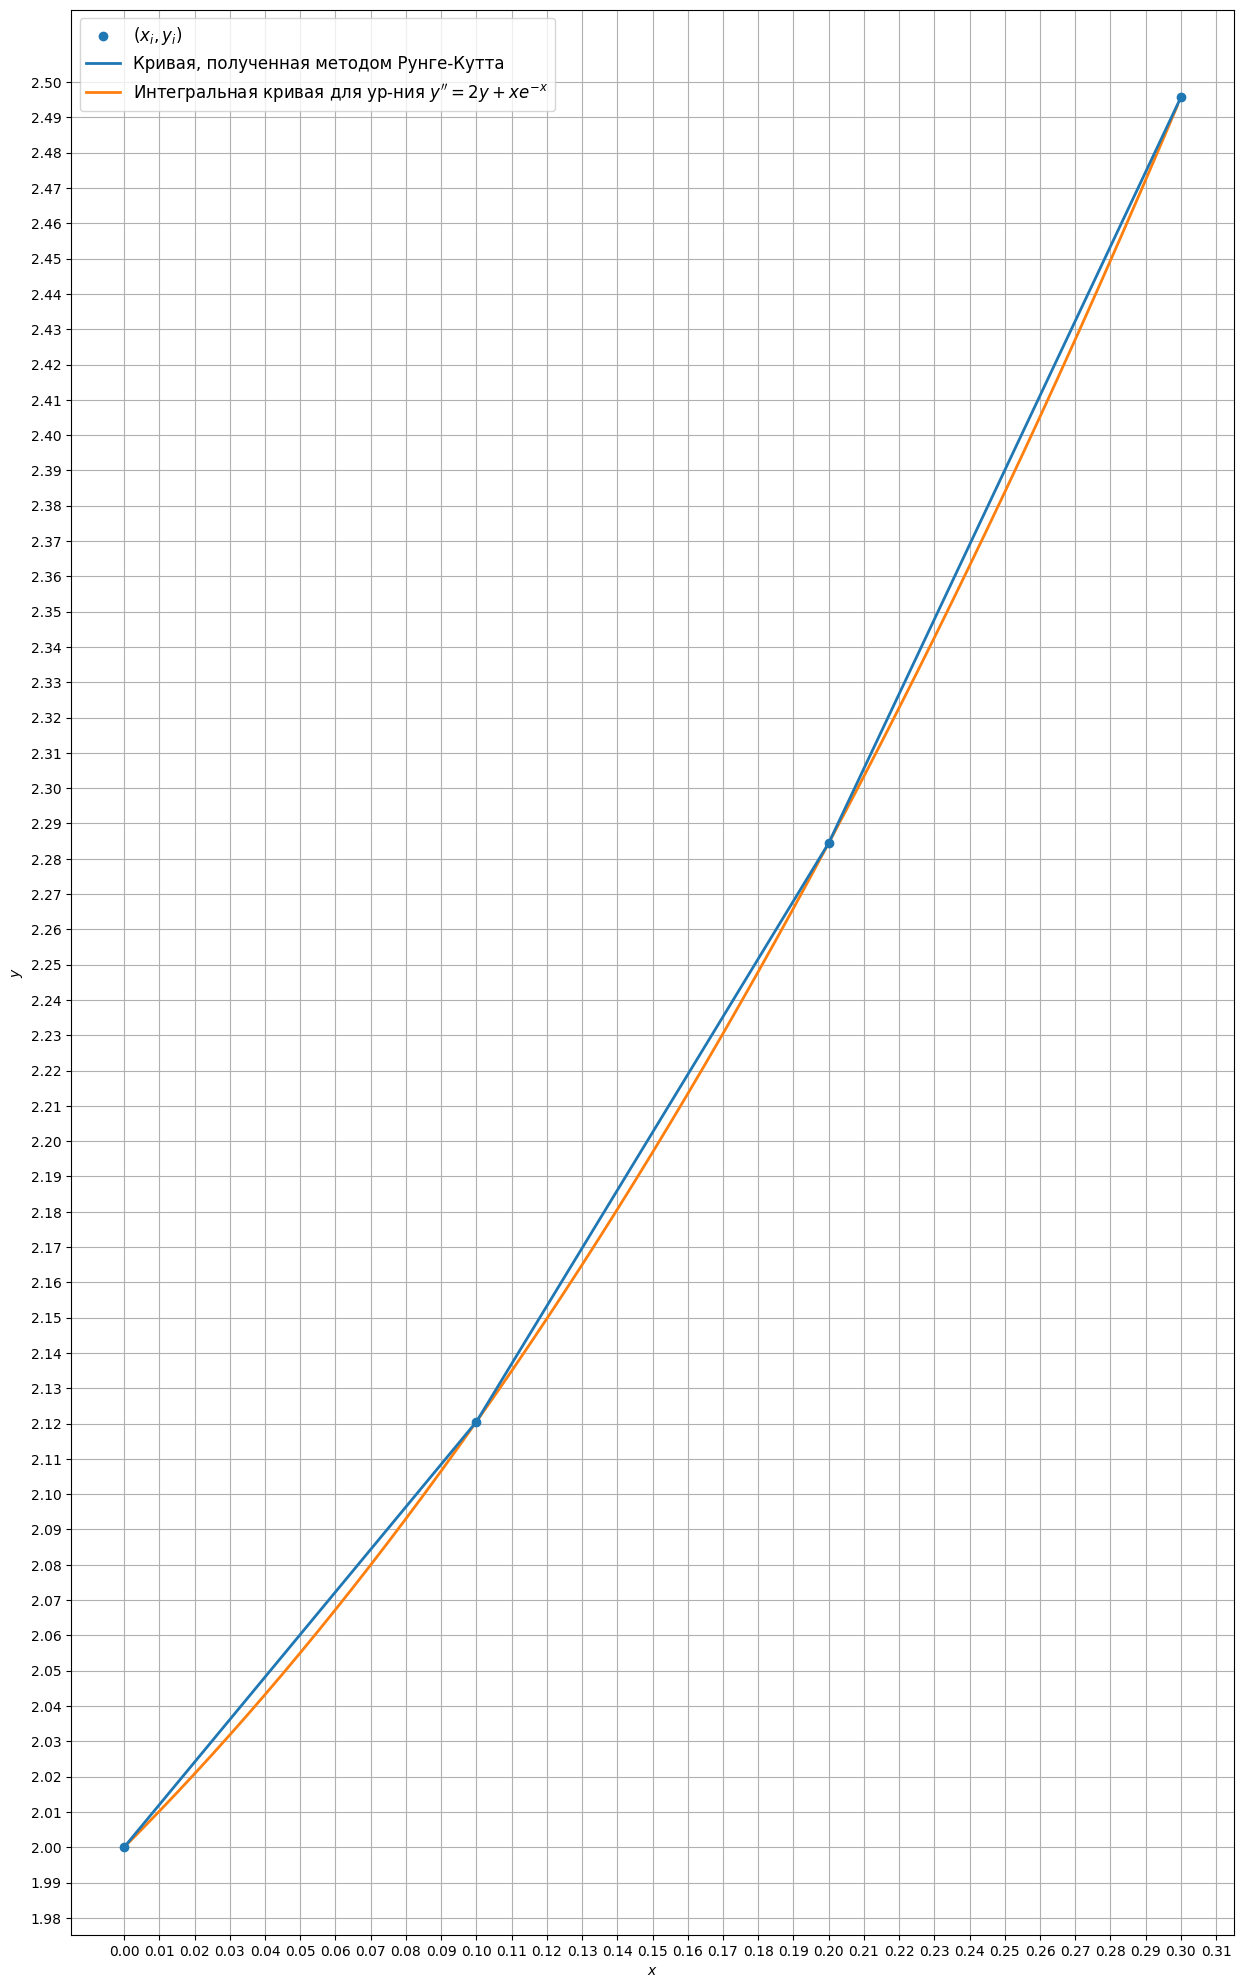

In [6]:
figure, axes = plt.subplots(figsize=(15, 25))
axes.set_axisbelow(True)
axes.set_xlabel(r"$x$")
axes.set_ylabel(r"$y$")
axes.set_xticks(np.arange(X[0], X[-1] + 0.1, 0.01))
axes.set_yticks(np.arange(Y[0] - 1, max(Y) + 0.01, 0.01))

axes.scatter(X, Y, zorder=2, label=r"$(x_i, y_i)$")
axes.plot(X, Y, zorder=2, linewidth=2, label=r"Кривая, полученная методом Рунге-Кутта")

true_X = np.arange(0, 0.3, 0.001)
true_Y = func(true_X)

axes.plot(true_X, true_Y, zorder=1, linewidth=2, label="Интегральная кривая для ур-ния " + r"$y''=2y+xe^{-x}$")


axes.grid()
axes.legend(fontsize="large")

C:\Users\Thunderobot\AppData\Local\Temp\ipykernel_9536\2377531874.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_xticklabels(map(lambda x: round(x, 6), axes.get_xticks()))
C:\Users\Thunderobot\AppData\Local\Temp\ipykernel_9536\2377531874.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_yticklabels(map(lambda x: round(x, 6), axes.get_yticks()))


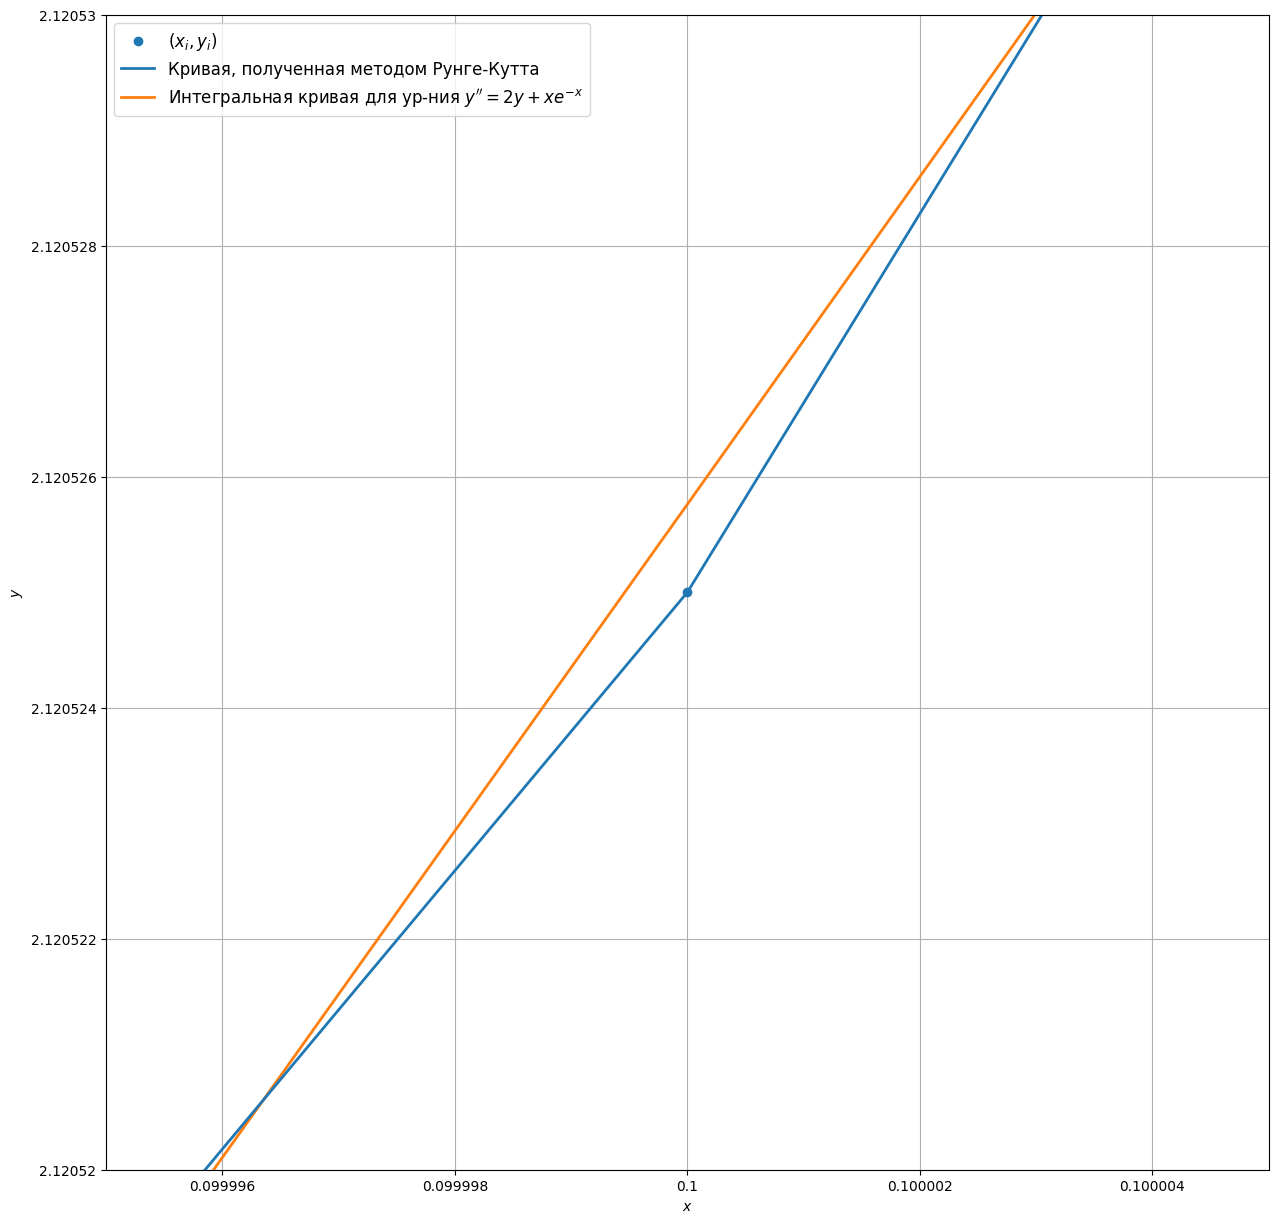

In [18]:
figure, axes = plt.subplots(figsize=(15, 15))
axes.set_xlim((X[1] - 0.000005, X[1] + 0.000005))
axes.set_ylim((Y[1] - 0.000005, Y[1] + 0.000005))
axes.set_axisbelow(True)
axes.set_xlabel(r"$x$")
axes.set_ylabel(r"$y$")
# axes.set_xticks(np.arange(X[0], X[-1] + 0.1, 0.01))
# axes.set_yticks(np.arange(Y[0] - 1, max(Y) + 0.01, 0.01))

axes.scatter(X, Y, zorder=2, label=r"$(x_i, y_i)$")
axes.plot(X, Y, zorder=2, linewidth=2, label=r"Кривая, полученная методом Рунге-Кутта")

true_X = np.arange(0, 0.3, 0.001)
true_Y = func(true_X)

axes.plot(true_X, true_Y, zorder=1, linewidth=2, label="Интегральная кривая для ур-ния " + r"$y''=2y+xe^{-x}$")
axes.set_xticklabels(map(lambda x: round(x, 6), axes.get_xticks()))
axes.set_yticklabels(map(lambda x: round(x, 6), axes.get_yticks()))

axes.grid()
axes.legend(fontsize="large")